# БДЗ 2

In [13]:
import sys
# sys.path.append("src")

In [14]:
import torch
from torch.utils.data import DataLoader
import torchtext
from pathlib import Path
import sacrebleu
from torch import nn

from src.dataset import TranslationDataset
from src.models.rnn import Seq2Seq
from src.train import train
from src.inference import translate_file
from src.prepare_spm import train_sentencepiece

In [15]:
print(f"PyTorch версия: {torch.__version__}")
print(f"torchtext версия: {torchtext.__version__}")
print(f"sacrebleu версия: {sacrebleu.__version__}")

PyTorch версия: 2.10.0
torchtext версия: 0.6.0
sacrebleu версия: 2.6.0


In [16]:
# обучение sentencepiece

DATA_DIR = "data"
FORCE_RETRAIN_SPM = False # принудительное пересоздание модели SentencePiece
VOCAB_SIZE = 2000

SPM_MODEL_PATH = Path(DATA_DIR) / "sentencepiece.model"

if not SPM_MODEL_PATH.exists() or FORCE_RETRAIN_SPM:
    print("SentencePiece model not found. Training...")
    train_sentencepiece(
        data_dir=DATA_DIR,
        vocab_size=VOCAB_SIZE,
        model_prefix="sentencepiece"
    )
else:
    print("SentencePiece model already exists.")

SentencePiece model already exists.


In [17]:
# даталоадеры

BATCH_SIZE = 64

train_ds = TranslationDataset(
    "train.de-en.de",
    "train.de-en.en",
    "sentencepiece.model"
)

val_ds = TranslationDataset(
    "val.de-en.de",
    "val.de-en.en",
    "sentencepiece.model"
)

PAD = train_ds.PAD
vocab_size = train_ds.vocab_size + 3

def make_collate(pad):
    def collate_fn(batch):
        srcs, tgts = zip(*batch)
        max_src = max(s.size(0) for s in srcs)
        max_tgt = max(t.size(0) for t in tgts)
        padded_src = torch.full((len(batch), max_src), pad, dtype=torch.long)
        padded_tgt = torch.full((len(batch), max_tgt), pad, dtype=torch.long)
        for i,(s,t) in enumerate(batch):
            padded_src[i, :s.size(0)] = s
            padded_tgt[i, :t.size(0)] = t
        src_lens = torch.LongTensor([s.size(0) for s in srcs])
        tgt_lens = torch.LongTensor([t.size(0) for t in tgts])
        return padded_src, src_lens, padded_tgt, tgt_lens
    return collate_fn

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=make_collate(PAD)
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=make_collate(PAD)
)

In [ ]:
# обрезка датасета для быстрого тестирования
DEBUG = False
DEBUG_SAMPLES = 20000

if DEBUG:
    train_ds.src_lines = train_ds.src_lines[:DEBUG_SAMPLES]
    train_ds.tgt_lines = train_ds.tgt_lines[:DEBUG_SAMPLES]

    print("Running in DEBUG mode")
    print("Train size:", len(train_ds))
    print("Val size:", len(val_ds))

In [19]:
print(len(train_ds.src_lines))
print(len(train_ds.tgt_lines))
print(len(val_ds.src_lines))
print(len(val_ds.tgt_lines))

195915
195915
986
986


In [ ]:
# параметры обучения

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

model = Seq2Seq(
    vocab_size,
    emb_size=128,
    hidden_size=256,
    n_layers=2,
    dropout=0.3,
    pad_idx=PAD
).to(device)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    if isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, mean=0, std=0.1)
model.apply(init_weights)


optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-6)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD)

NUM_EPOCHS = 50

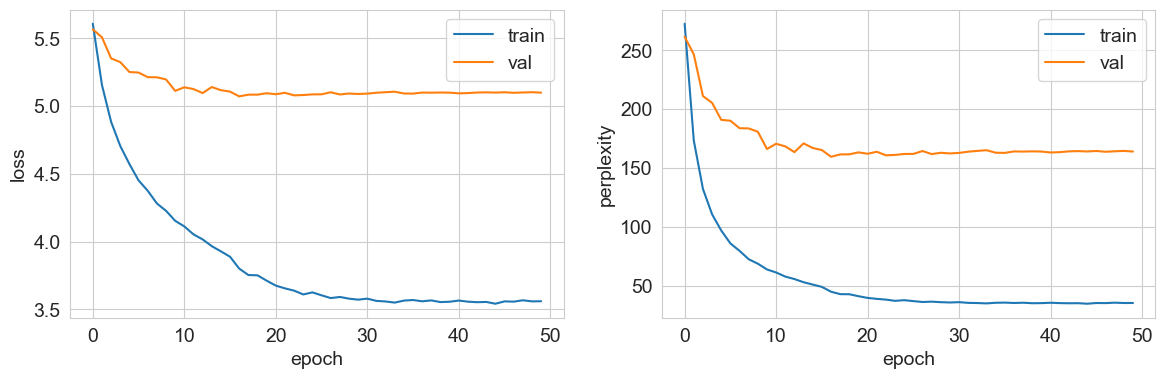

In [8]:
# обучение модели
train_losses, val_losses, train_ppls, val_ppls = train(
    model,
    optimizer,
    scheduler,
    criterion,
    train_loader,
    val_loader,
    PAD,
    num_epochs=NUM_EPOCHS,
    plot=True
)

In [24]:
# BLEU на валидации

val_src = open("data/val.de-en.de", encoding="utf-8").read().splitlines()
val_ref = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

VAL_OUTPUT_PATH = "outputs/val_predictions.en"

translate_file(
    model=model,
    dataset=val_ds,
    input_lines=val_src,
    device=device,
    output_path=VAL_OUTPUT_PATH,
    max_decoding_len=50
)

val_pred = open(VAL_OUTPUT_PATH, encoding="utf-8").read().splitlines()

bleu = sacrebleu.corpus_bleu(val_pred, [val_ref])
print("Validation BLEU:", bleu.score)

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Validation BLEU: 8.168694182505085


In [10]:
# quick diagnostics
import re
from pprint import pprint

# загрузите предсказания и референсы (как вы делаете)
val_pred = open("outputs/val_predictions.en", encoding="utf-8").read().splitlines()
val_ref  = open("data/val.de-en.en", encoding="utf-8").read().splitlines()

print("counts: pred =", len(val_pred), "ref =", len(val_ref))

# посмотрим на первые 10 примеров в repr-форме, чтобы увидеть пробелы/токены
for i in range(10):
    print(f"\n=== Example {i} ===")
    print("PRED repr:", repr(val_pred[i]))
    print("REF  repr:", repr(val_ref[i]))

counts: pred = 986 ref = 986

=== Example 0 ===
PRED repr: 'when i 11 11 years , i waswent to a a a of the ss of the ss . . . .'
REF  repr: 'when i was 11 , i remember waking up one morning to the sound of joy in my house .'

=== Example 1 ===
PRED repr: 'my father was sited on his friends , , , thess thesss of the bac . . .'
REF  repr: 'my father was listening to bbc news on his small , gray radio .'

=== Example 2 ===
PRED repr: 'he was very happy very , what was was pretty unfully unforted , , he was the most ofss most ofs . . . . . . .'
REF  repr: 'there was a big smile on his face which was unusual then , because the news mostly depressed him .'

=== Example 3 ===
PRED repr: 'he \'s " : " the theliban \'s  ! " "'
REF  repr: '" the taliban are gone ! " my father shouted .'

=== Example 4 ===
PRED repr: 'i knn know what what means , but it wass my father , but it was very ver very very very happy .'
REF  repr: "i didn 't know what it meant , but i could see that my father was very ,

In [11]:
# прогноз для тестового набора

test_lines = open("data/test1.de-en.de", encoding="utf-8").read().splitlines()

OUTPUT_PATH = "outputs/test1.de-en.en"

translate_file(
    model=model,
    dataset=train_ds,
    input_lines=test_lines,
    device=device,
    output_path=OUTPUT_PATH,
    max_decoding_len=50
)

print(f"Test translations saved to {OUTPUT_PATH}")

Test translations saved to outputs/test1.de-en.en
